# Notebook 01 — Yield Curve Construction from First Principles

## Fixed Income From Scratch

**Objective:** Build the analytical foundation that everything else depends on — the risk-free yield curve.

Every fixed-income valuation ultimately reduces to discounting cash flows. The discount rates come from the yield curve. Get this wrong, and every downstream calculation (spreads, OAS, duration, hedging) inherits the error.

### What We'll Build:
1. **Treasury Zero Curve** — Bootstrap zero-coupon rates from par yields
2. **Swap Zero Curve** — Bootstrap from deposit rates and swap par rates  
3. **Forward Rates** — Extract the market's implied future rate expectations
4. **Interpolation Methods** — Compare linear, cubic spline, and monotone convex
5. **Curve Manipulation** — Parallel shifts, twists, butterflies, key-rate bumps

### Why This Matters:
- The zero curve is the **pricing backbone** for every security in the portfolio
- Forward rates feed directly into the **BGM model** for Monte Carlo simulation (Notebook 06)
- Curve shifts drive **scenario analysis** and **duration/convexity** calculations
- The Treasury-Swap basis is a key **relative value signal**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys, os

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from utils.curves import (
    bootstrap_treasury_curve, bootstrap_swap_curve,
    compute_forward_curve, ZeroCurve,
    continuous_to_semi_annual, sample_treasury_data, sample_swap_data,
    linear_interpolation, cubic_spline_interpolation, monotone_convex_interpolation,
    discount_factors_from_zeros
)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Modules loaded successfully.")

Modules loaded successfully.


---
## 1. Market Data: Treasury Par Yields

In practice, you'd pull this from FRED (Federal Reserve Economic Data) using:
```python
from fredapi import Fred
fred = Fred(api_key='YOUR_KEY')
ust_10y = fred.get_series('DGS10')
```

For reproducibility, we use a realistic snapshot of the Treasury par yield curve from early 2024 — an **inverted curve** where short rates exceed long rates. This inversion is economically meaningful: the market is pricing in rate cuts, implying the Fed funds rate will decline.

**Key tenors and what they represent:**
- **1M-6M**: T-bills (zero-coupon, pure discount instruments)  
- **1Y-3Y**: Front end, most sensitive to Fed policy expectations
- **5Y-7Y**: Belly, where most mortgage duration sits
- **10Y**: Benchmark for mortgage rates (30Y mortgage ~ 10Y Treasury + spread)
- **20Y-30Y**: Long end, driven by term premium and supply/demand

In [5]:
# Load sample Treasury par yields
tenors, par_yields = sample_treasury_data()

# Display the raw data
tenor_labels = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
data_display = pd.DataFrame({
    'Tenor': tenor_labels,
    'Maturity (Yrs)': tenors,
    'Par Yield (%)': par_yields * 100
}).set_index('Tenor')

print("Treasury Par Yield Curve (as of early 2024)")
print("=" * 50)
print(data_display.to_string())
print(f"\nCurve shape: {'INVERTED' if par_yields[0] > par_yields[-1] else 'NORMAL'}")
print(f"2s10s spread: {(par_yields[8] - par_yields[4]) * 10000:.0f} bps")
print(f"2s30s spread: {(par_yields[10] - par_yields[4]) * 10000:.0f} bps")

Treasury Par Yield Curve (as of early 2024)
       Maturity (Yrs)  Par Yield (%)
Tenor                               
1M           0.083333           5.40
3M           0.250000           5.35
6M           0.500000           5.15
1Y           1.000000           4.80
2Y           2.000000           4.40
3Y           3.000000           4.15
5Y           5.000000           4.00
7Y           7.000000           4.10
10Y         10.000000           4.20
20Y         20.000000           4.55
30Y         30.000000           4.45

Curve shape: INVERTED
2s10s spread: -20 bps
2s30s spread: 5 bps


---
## 2. Bootstrapping the Zero-Coupon Curve

### The Problem
Market-quoted Treasury yields are **par yields** — the coupon rate at which a bond prices at par (100). But for discounting arbitrary cash flows, we need **zero-coupon rates** — the yield on a hypothetical bond that pays no coupons, only principal at maturity.

### The Method
Bootstrapping solves for zero rates iteratively:

**Short end (T-bills, <= 6M):** These are already zero-coupon instruments.

$$r_{zero}(T) = \\frac{\\ln(1 + y_{par} \\cdot T)}{T}$$

**Long end (coupon bonds):** For a bond with par yield $c$ at maturity $T$, we know all previous zero rates. Solve for $r(T)$ using:

$$1 = \\sum_{i=1}^{n-1} \\frac{c/f}{e^{r(t_i) \\cdot t_i}} + \\frac{1 + c/f}{e^{r(T) \\cdot T}}$$

### Why continuously compounded?
We store all zero rates as **continuously compounded** internally. This simplifies the math:
- Discount factors: $D(0,T) = e^{-r \\cdot T}$  
- Forward rates: $f(t_1,t_2) = \\frac{r(t_2) \\cdot t_2 - r(t_1) \\cdot t_1}{t_2 - t_1}$
- No compounding frequency ambiguity

We convert to semi-annual (market convention) only for display.

In [8]:
# Bootstrap the Treasury zero curve
tsy_curve = bootstrap_treasury_curve(tenors, par_yields, freq=2)

# Display results: compare par yields vs zero rates
zero_rates_sa = continuous_to_semi_annual(tsy_curve.zero_rates)

comparison = pd.DataFrame({
    'Tenor': tenor_labels,
    'Par Yield (%)': par_yields * 100,
    'Zero Rate - CC (%)': tsy_curve.zero_rates * 100,
    'Zero Rate - SA (%)': zero_rates_sa * 100,
    'Discount Factor': tsy_curve.discount_factor(tenors)
}).set_index('Tenor')

print("Treasury Curve: Par Yields vs Bootstrapped Zero Rates")
print("=" * 70)
print(comparison.round(4).to_string())
print()
print("CC = Continuously Compounded | SA = Semi-Annual (market convention)")
print()
print("Note: Zero rates EXCEED par yields for most tenors. This is because")
print("par yields are a weighted average of zero rates up to that maturity.")
print("The zero curve 'strips out' the coupon effect, revealing the true")
print("term structure of discount rates.")

Treasury Curve: Par Yields vs Bootstrapped Zero Rates
       Par Yield (%)  Zero Rate - CC (%)  Zero Rate - SA (%)  Discount Factor
Tenor                                                                        
1M              5.40              5.3879              5.4611           0.9955
3M              5.35              5.3145              5.3858           0.9868
6M              5.15              5.0848              5.1500           0.9749
1Y              4.80              4.7392              4.7958           0.9537
2Y              4.40              4.3407              4.3881           0.9168
3Y              4.15              4.0894              4.1315           0.8845
5Y              4.00              3.9402              3.9793           0.8212
7Y              4.10              4.0548              4.0962           0.7529
10Y             4.20              4.1706              4.2144           0.6590
20Y             4.55              4.6237              4.6775           0.3966
30Y       

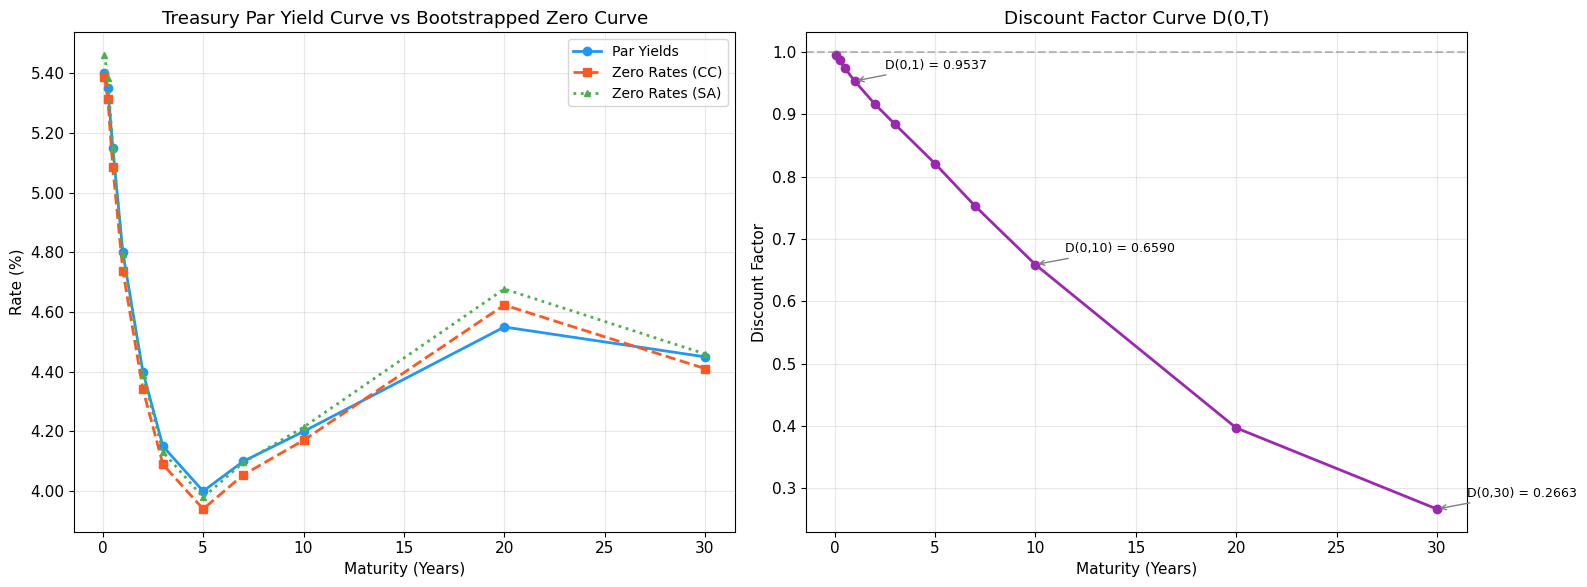


$1 received in 30 years is worth $0.2663 today


In [10]:
# Visualize: Par Yield vs Zero Rate vs Discount Factors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Yield curves
ax1.plot(tenors, par_yields * 100, 'o-', label='Par Yields', linewidth=2, markersize=6, color='#2196F3')
ax1.plot(tenors, tsy_curve.zero_rates * 100, 's--', label='Zero Rates (CC)', linewidth=2, markersize=6, color='#FF5722')
ax1.plot(tenors, zero_rates_sa * 100, '^:', label='Zero Rates (SA)', linewidth=2, markersize=5, color='#4CAF50')
ax1.set_xlabel('Maturity (Years)')
ax1.set_ylabel('Rate (%)')
ax1.set_title('Treasury Par Yield Curve vs Bootstrapped Zero Curve')
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Right: Discount factors
ax2.plot(tenors, tsy_curve.discount_factor(tenors), 'o-', linewidth=2, markersize=6, color='#9C27B0')
ax2.set_xlabel('Maturity (Years)')
ax2.set_ylabel('Discount Factor')
ax2.set_title('Discount Factor Curve D(0,T)')
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

for t, df_val in zip([1, 10, 30], [tsy_curve.discount_factor(np.array([t]))[0] for t in [1, 10, 30]]):
    ax2.annotate(f'D(0,{t}) = {df_val:.4f}', xy=(t, df_val), 
                 xytext=(t+1.5, df_val+0.02), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()
print(f"\n$1 received in 30 years is worth ${tsy_curve.discount_factor(np.array([30]))[0]:.4f} today")

---
## 3. Swap Curve Construction

### Why a Separate Swap Curve?

The Treasury curve reflects sovereign credit (risk-free in nominal terms). The swap curve reflects **interbank credit** — historically LIBOR, now SOFR. The difference matters:

- **MBS pricing** uses the Treasury curve for spread calculations but the **swap curve for hedging**
- **OAS calculations** can be run against either curve — the choice affects the OAS level
- The **Treasury-swap basis** itself is a tradable spread that fluctuates with supply/demand and dealer balance sheet constraints

### Bootstrap Methodology
Same iterative approach as Treasuries, but with different day-count conventions:
- **Short end**: SOFR/LIBOR deposits (simple compounding, Act/360)
- **Long end**: Par swap rates (the fixed rate making the swap NPV = 0)

In [13]:
# Load swap curve data and bootstrap
dep_tenors, dep_rates, swap_tenors, swap_rates = sample_swap_data()
swap_curve = bootstrap_swap_curve(dep_tenors, dep_rates, swap_tenors, swap_rates)

# Compare Treasury vs Swap curves at common tenors
common_tenors = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])
tsy_zeros = tsy_curve.interpolate(common_tenors)
swap_zeros = swap_curve.interpolate(common_tenors)
basis = (swap_zeros - tsy_zeros) * 10000

comparison_curves = pd.DataFrame({
    'Tenor': common_tenors,
    'Treasury Zero (%)': tsy_zeros * 100,
    'Swap Zero (%)': swap_zeros * 100,
    'Swap Spread (bps)': basis
}).set_index('Tenor')

print("Treasury vs Swap Zero Curves")
print("=" * 60)
print(comparison_curves.round(2).to_string())
print(f"\nAverage swap spread: {basis.mean():.1f} bps")

Treasury vs Swap Zero Curves
       Treasury Zero (%)  Swap Zero (%)  Swap Spread (bps)
Tenor                                                     
0.25                5.31           5.36               4.93
0.50                5.08           5.23              14.62
1.00                4.74           4.84               9.70
2.00                4.34           4.44               9.73
3.00                4.09           4.24              14.83
5.00                3.94           4.09              14.74
7.00                4.05           4.15               9.30
10.00               4.17           4.21               3.72
20.00               4.62           4.46             -16.77
30.00               4.41           4.27             -13.87

Average swap spread: 5.1 bps


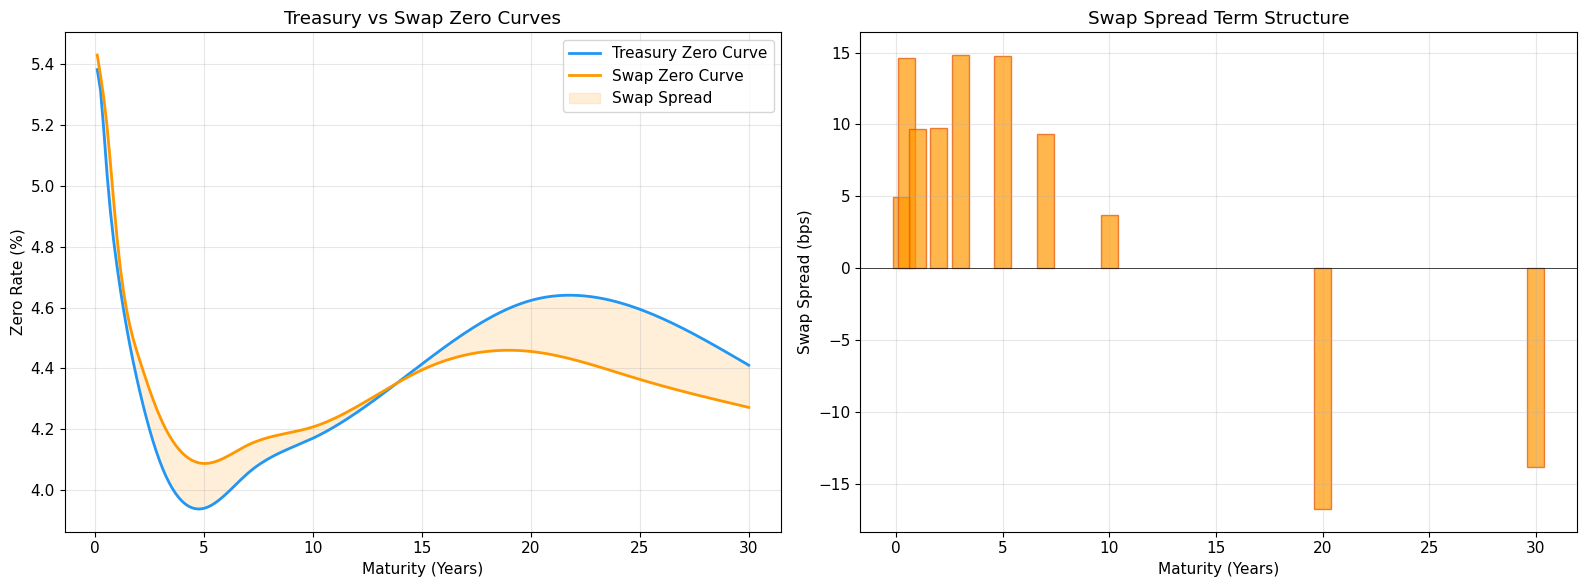

In [15]:
# Visualize Treasury vs Swap curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

t_dense = np.linspace(0.1, 30, 200)
tsy_dense = tsy_curve.interpolate(t_dense) * 100
swap_dense = swap_curve.interpolate(t_dense) * 100

ax1.plot(t_dense, tsy_dense, '-', label='Treasury Zero Curve', linewidth=2, color='#2196F3')
ax1.plot(t_dense, swap_dense, '-', label='Swap Zero Curve', linewidth=2, color='#FF9800')
ax1.fill_between(t_dense, tsy_dense, swap_dense, alpha=0.15, color='#FF9800', label='Swap Spread')
ax1.set_xlabel('Maturity (Years)')
ax1.set_ylabel('Zero Rate (%)')
ax1.set_title('Treasury vs Swap Zero Curves')
ax1.legend()

ax2.bar(common_tenors, basis, width=0.8, color='#FF9800', alpha=0.7, edgecolor='#E65100')
ax2.set_xlabel('Maturity (Years)')
ax2.set_ylabel('Swap Spread (bps)')
ax2.set_title('Swap Spread Term Structure')
ax2.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

---
## 4. Forward Rate Extraction

The forward rate $f(t_1, t_2)$ is the interest rate, **implied by today's curve**, for borrowing between future times $t_1$ and $t_2$.

From no-arbitrage:

$$f(t_1,t_2) = \\frac{r(t_2) \\cdot t_2 - r(t_1) \\cdot t_1}{t_2 - t_1}$$

### Why This Matters for MBS:
1. **BGM Model** (Notebook 06): evolves **forward rates** directly — today's forward curve is the starting state
2. **ARM Resets**: adjustable-rate mortgages reset to an index rate — forwards project those resets
3. **Prepayment Modeling**: refinancing incentive on each Monte Carlo path depends on projected mortgage rate
4. **Curve Shape**: an inverted spot curve with upward-sloping forwards signals expected rate cuts then normalization

In [18]:
# Compute forward curves
fwd_6m_times, fwd_6m_rates = compute_forward_curve(tsy_curve, period=0.5)
fwd_1y_times, fwd_1y_rates = compute_forward_curve(tsy_curve, period=1.0)

# Instantaneous forwards
t_inst = np.linspace(0.1, 29.9, 200)
inst_fwd = tsy_curve.instantaneous_forward(t_inst)

print("Selected Forward Rates (Treasury Curve)")
print("=" * 55)
key_forwards = [
    ("1Y rate, 1Y forward", tsy_curve.forward_rate(1, 2)),
    ("1Y rate, 2Y forward", tsy_curve.forward_rate(2, 3)),
    ("1Y rate, 5Y forward", tsy_curve.forward_rate(5, 6)),
    ("5Y rate, 5Y forward", tsy_curve.forward_rate(5, 10)),
    ("10Y rate, 10Y forward", tsy_curve.forward_rate(10, 20)),
    ("10Y rate, 20Y forward", tsy_curve.forward_rate(20, 30)),
]
for label, rate in key_forwards:
    print(f"  {label:30s}: {rate*100:.3f}%")

print()
spot_2y = float(tsy_curve.interpolate(np.array([2]))[0])
fwd_2_10 = tsy_curve.forward_rate(2, 10)
print(f"Spot 2Y: {spot_2y*100:.3f}% | Implied 8Y rate starting in 2Y: {fwd_2_10*100:.3f}%")
print(f"The market implies rates will {'FALL' if fwd_2_10 < spot_2y else 'RISE'} from current 2Y levels.")

Selected Forward Rates (Treasury Curve)
  1Y rate, 1Y forward           : 3.942%
  1Y rate, 2Y forward           : 3.587%
  1Y rate, 5Y forward           : 4.218%
  5Y rate, 5Y forward           : 4.401%
  10Y rate, 10Y forward         : 5.077%
  10Y rate, 20Y forward         : 3.985%

Spot 2Y: 4.341% | Implied 8Y rate starting in 2Y: 4.128%
The market implies rates will FALL from current 2Y levels.


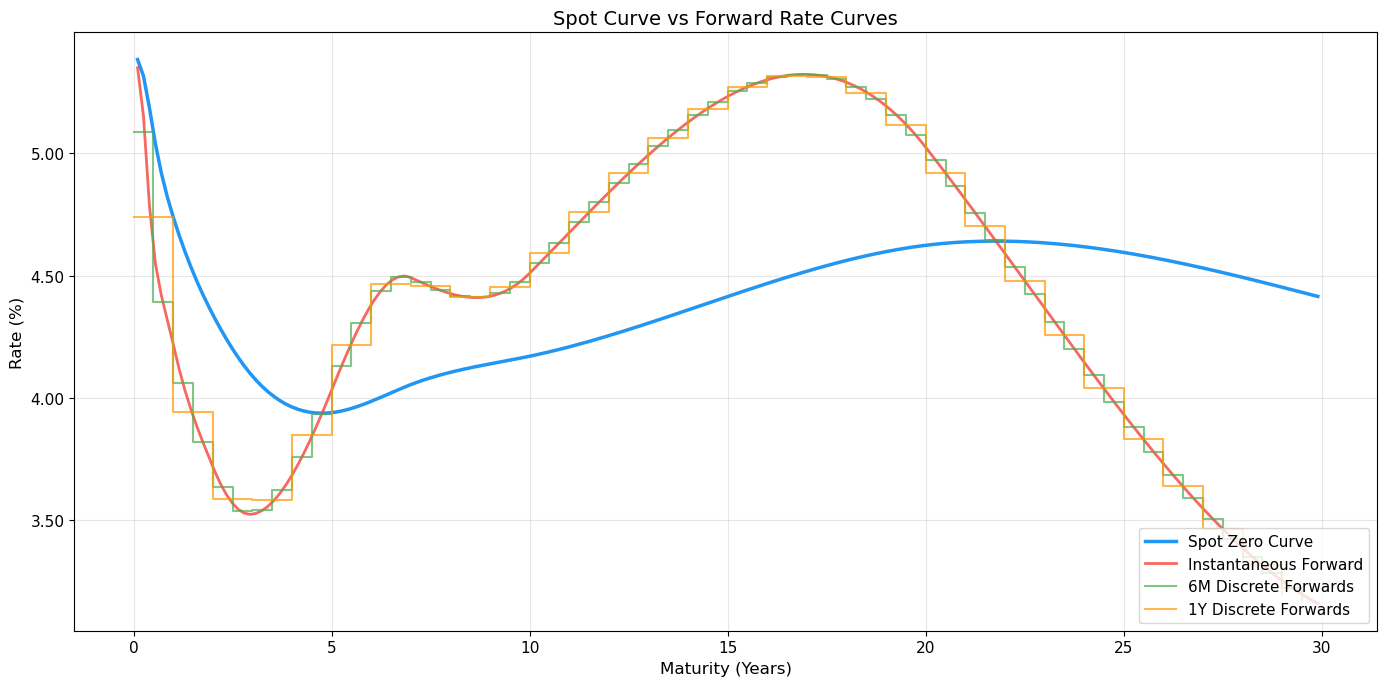

In [20]:
# Visualize: Spot vs Forward curves
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(t_inst, tsy_curve.interpolate(t_inst) * 100, '-', 
        label='Spot Zero Curve', linewidth=2.5, color='#2196F3')
ax.plot(t_inst, inst_fwd * 100, '-', 
        label='Instantaneous Forward', linewidth=2, color='#F44336', alpha=0.8)
ax.step(fwd_6m_times, fwd_6m_rates * 100, where='post',
        label='6M Discrete Forwards', linewidth=1.5, color='#4CAF50', alpha=0.7)
ax.step(fwd_1y_times, fwd_1y_rates * 100, where='post',
        label='1Y Discrete Forwards', linewidth=1.5, color='#FF9800', alpha=0.7)

ax.set_xlabel('Maturity (Years)', fontsize=12)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_title('Spot Curve vs Forward Rate Curves', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

---
## 5. Interpolation Method Comparison

We only observe rates at discrete tenors, but need rates at arbitrary points. The interpolation method affects:

1. **Smoothness of forward rates**: Linear interpolation creates **discontinuous forwards**
2. **Stability of hedge ratios**: Jagged forwards make partial durations noisy
3. **OAS accuracy**: Monte Carlo paths sample the curve at arbitrary tenors

### Methods Compared:
- **Linear**: Simple but discontinuous forwards — creates artifacts
- **Cubic Spline**: Smooth forwards but can oscillate and produce negative rates
- **Monotone Convex**: Preserves monotonicity of discount factors while maintaining smooth forwards — industry best practice (Hagan & West, 2006)

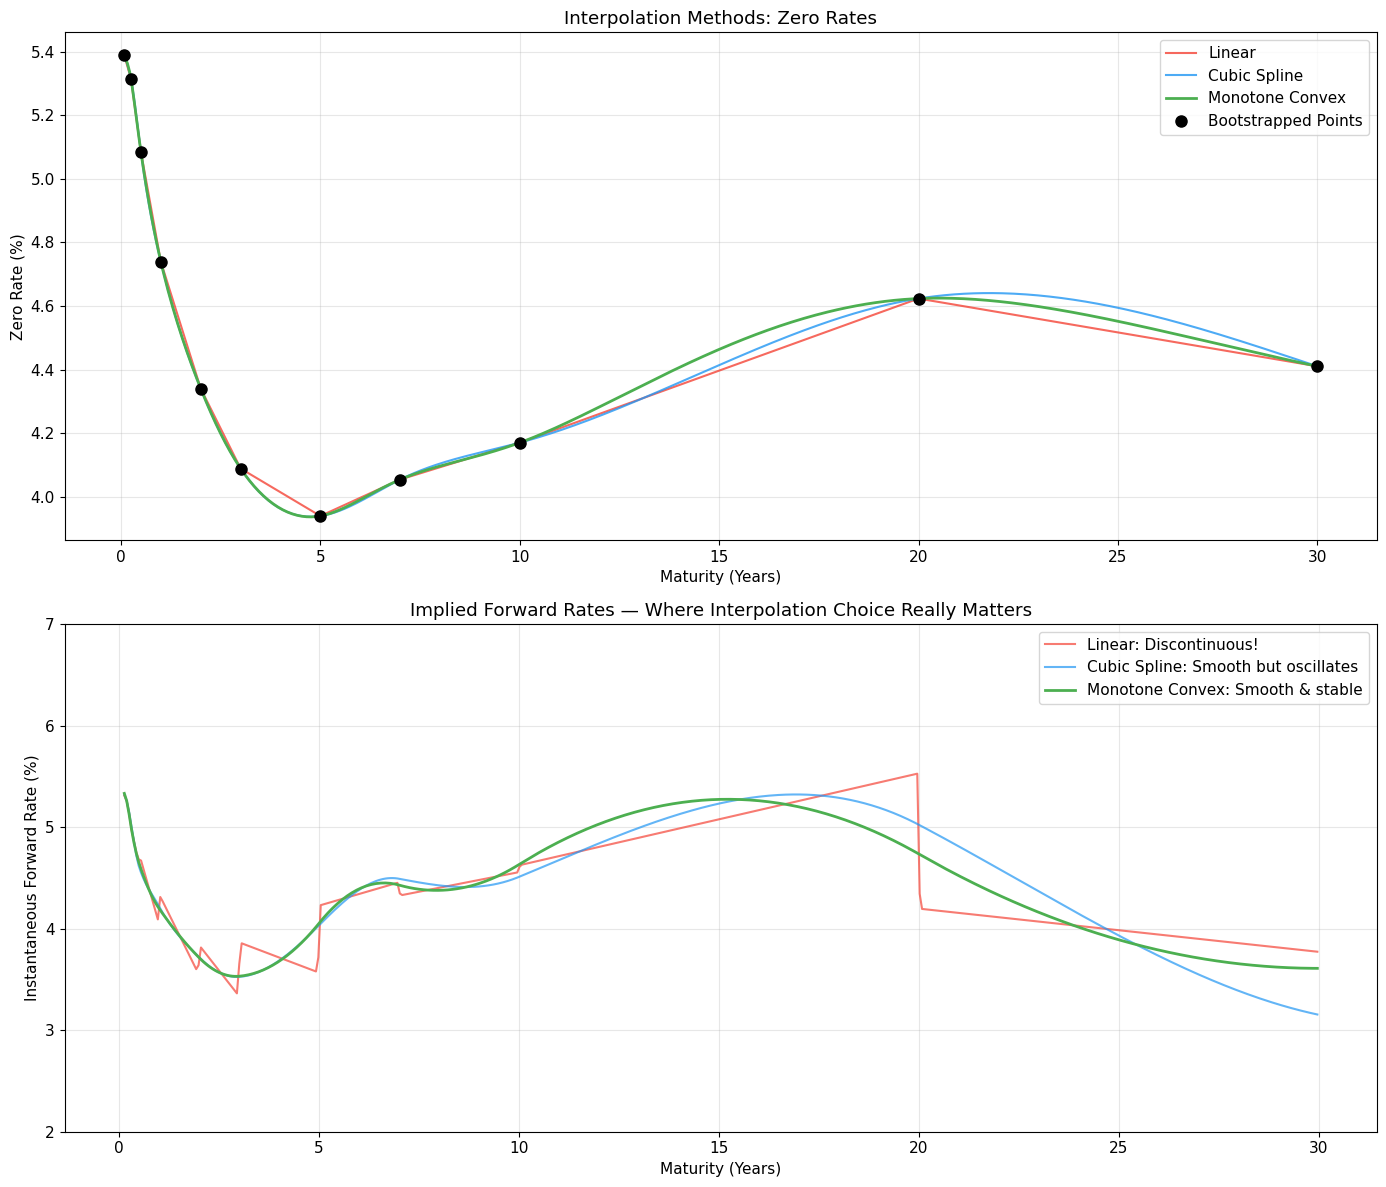

KEY OBSERVATION: All three methods agree at the knot points,
but diverge significantly between knots — especially in forward space.
Linear produces unrealistic jumps. Cubic spline oscillates. Monotone convex wins.


In [23]:
# Compare interpolation methods
t_fine = np.linspace(0.1, 30, 500)

rates_linear = linear_interpolation(tenors, tsy_curve.zero_rates, t_fine)
rates_cubic = cubic_spline_interpolation(tenors, tsy_curve.zero_rates, t_fine)
rates_monotone = monotone_convex_interpolation(tenors, tsy_curve.zero_rates, t_fine)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top: Zero rates
ax1 = axes[0]
ax1.plot(t_fine, rates_linear * 100, '-', label='Linear', linewidth=1.5, alpha=0.8, color='#F44336')
ax1.plot(t_fine, rates_cubic * 100, '-', label='Cubic Spline', linewidth=1.5, alpha=0.8, color='#2196F3')
ax1.plot(t_fine, rates_monotone * 100, '-', label='Monotone Convex', linewidth=2, color='#4CAF50')
ax1.plot(tenors, tsy_curve.zero_rates * 100, 'ko', markersize=8, label='Bootstrapped Points', zorder=5)
ax1.set_xlabel('Maturity (Years)')
ax1.set_ylabel('Zero Rate (%)')
ax1.set_title('Interpolation Methods: Zero Rates')
ax1.legend(fontsize=11)

# Bottom: Implied forward rates
fwd_linear = (rates_linear[1:] * t_fine[1:] - rates_linear[:-1] * t_fine[:-1]) / (t_fine[1:] - t_fine[:-1])
fwd_cubic = (rates_cubic[1:] * t_fine[1:] - rates_cubic[:-1] * t_fine[:-1]) / (t_fine[1:] - t_fine[:-1])
fwd_monotone = (rates_monotone[1:] * t_fine[1:] - rates_monotone[:-1] * t_fine[:-1]) / (t_fine[1:] - t_fine[:-1])
t_fwd = (t_fine[1:] + t_fine[:-1]) / 2

ax2 = axes[1]
ax2.plot(t_fwd, fwd_linear * 100, '-', label='Linear: Discontinuous!', linewidth=1.5, alpha=0.7, color='#F44336')
ax2.plot(t_fwd, fwd_cubic * 100, '-', label='Cubic Spline: Smooth but oscillates', linewidth=1.5, alpha=0.7, color='#2196F3')
ax2.plot(t_fwd, fwd_monotone * 100, '-', label='Monotone Convex: Smooth & stable', linewidth=2, color='#4CAF50')
ax2.set_xlabel('Maturity (Years)')
ax2.set_ylabel('Instantaneous Forward Rate (%)')
ax2.set_title('Implied Forward Rates — Where Interpolation Choice Really Matters')
ax2.legend(fontsize=11)
ax2.set_ylim([2, 7])

plt.tight_layout()
plt.show()

print("KEY OBSERVATION: All three methods agree at the knot points,")
print("but diverge significantly between knots — especially in forward space.")
print("Linear produces unrealistic jumps. Cubic spline oscillates. Monotone convex wins.")

---
## 6. Curve Manipulation — Scenario Building Blocks

Every scenario analysis and risk measure starts with a curve shift:

| Shift Type | Economic Interpretation |
|:-----------|:----------------------|
| **Parallel** | Fed hikes/cuts uniformly, general risk repricing |
| **Twist (Steepening)** | Growth expectations rise, term premium increases |
| **Twist (Flattening)** | Recession fears, flight to quality |
| **Butterfly** | Belly cheapens/richens relative to wings |
| **Key-Rate** | Localized move — isolates exposure at a specific maturity |

These feed directly into duration/convexity (Notebook 07), partial duration, and scenario P&L (Notebook 08).

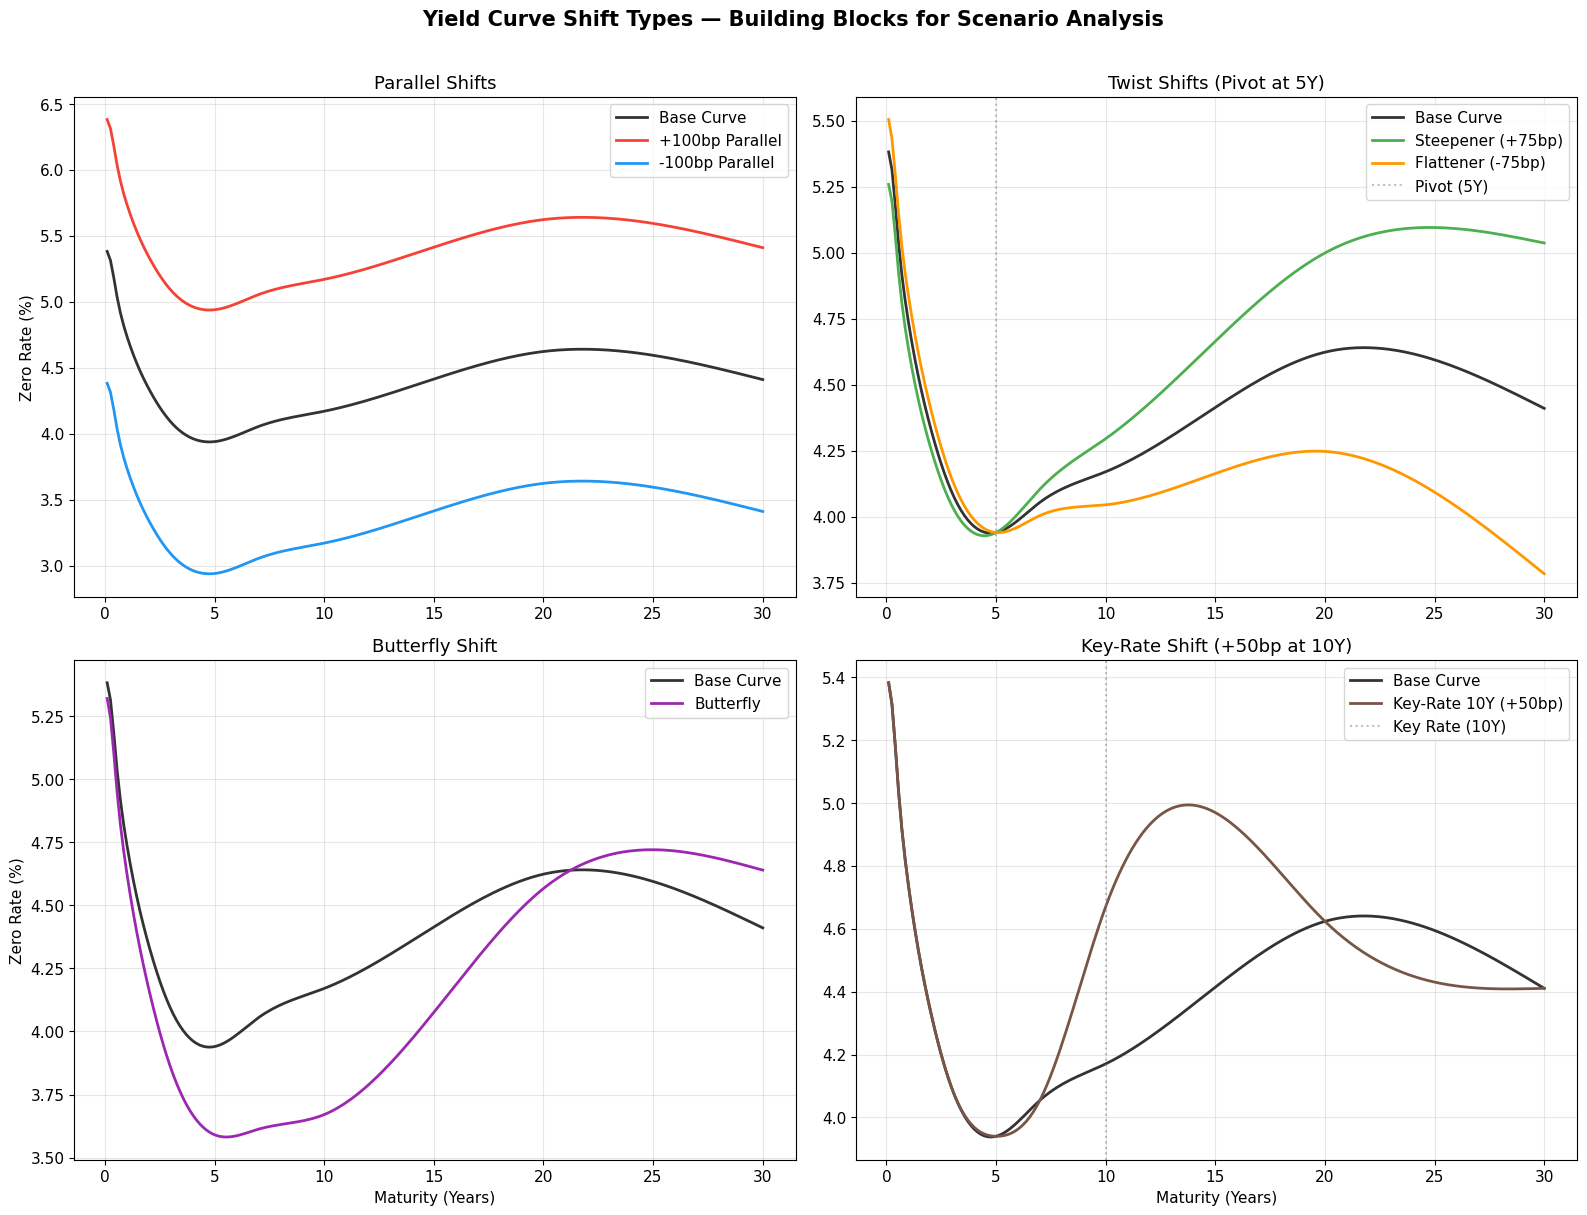

In [26]:
# Generate all shift types
shifts = {
    'Base Curve': tsy_curve,
    '+100bp Parallel': tsy_curve.shift('parallel', shift_bps=100),
    '-100bp Parallel': tsy_curve.shift('parallel', shift_bps=-100),
    'Steepener (+75bp)': tsy_curve.shift('twist', shift_bps=75, pivot_tenor=5),
    'Flattener (-75bp)': tsy_curve.shift('twist', shift_bps=-75, pivot_tenor=5),
    'Butterfly': tsy_curve.shift('butterfly', shift_bps=50, pivot_tenor=10, wing_shift_bps=25),
    'Key-Rate 10Y (+50bp)': tsy_curve.shift('key_rate', shift_bps=50, key_rate_tenor=10, key_rate_width=3),
}

t_dense = np.linspace(0.1, 30, 200)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['#333333', '#F44336', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#795548']

# Parallel shifts
ax = axes[0, 0]
for (name, curve), color in zip(list(shifts.items())[:3], colors[:3]):
    ax.plot(t_dense, curve.interpolate(t_dense) * 100, '-', label=name, linewidth=2, color=color)
ax.set_title('Parallel Shifts', fontsize=13); ax.legend(); ax.set_ylabel('Zero Rate (%)')

# Twist shifts
ax = axes[0, 1]
for name, idx in [('Base Curve', 0), ('Steepener (+75bp)', 3), ('Flattener (-75bp)', 4)]:
    ax.plot(t_dense, shifts[name].interpolate(t_dense) * 100, '-', label=name, linewidth=2, color=colors[idx])
ax.axvline(x=5, color='gray', linestyle=':', alpha=0.5, label='Pivot (5Y)')
ax.set_title('Twist Shifts (Pivot at 5Y)', fontsize=13); ax.legend()

# Butterfly
ax = axes[1, 0]
for name, idx in [('Base Curve', 0), ('Butterfly', 5)]:
    ax.plot(t_dense, shifts[name].interpolate(t_dense) * 100, '-', label=name, linewidth=2, color=colors[idx])
ax.set_title('Butterfly Shift', fontsize=13); ax.legend()
ax.set_ylabel('Zero Rate (%)'); ax.set_xlabel('Maturity (Years)')

# Key-rate
ax = axes[1, 1]
for name, idx in [('Base Curve', 0), ('Key-Rate 10Y (+50bp)', 6)]:
    ax.plot(t_dense, shifts[name].interpolate(t_dense) * 100, '-', label=name, linewidth=2, color=colors[idx])
ax.axvline(x=10, color='gray', linestyle=':', alpha=0.5, label='Key Rate (10Y)')
ax.set_title('Key-Rate Shift (+50bp at 10Y)', fontsize=13); ax.legend()
ax.set_xlabel('Maturity (Years)')

plt.suptitle('Yield Curve Shift Types — Building Blocks for Scenario Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Consistency Check: Par Rate Round-Trip

If bootstrapping is correct, we should recover the original par yields exactly from the zero curve:

$$c = f \\times \\frac{1 - D(0,T)}{\\sum_{i=1}^{n} D(0,t_i)}$$

In [29]:
# Verify: reconstruct par yields from zero curve
reconstructed = np.array([tsy_curve.par_rate(t) for t in tenors])

verification = pd.DataFrame({
    'Tenor': tenor_labels,
    'Original Par Yield (%)': par_yields * 100,
    'Reconstructed (%)': reconstructed * 100,
    'Error (bps)': (reconstructed - par_yields) * 10000
}).set_index('Tenor')

print("Bootstrap Verification: Par Rate Round-Trip")
print("=" * 60)
print(verification.round(6).to_string())
max_err = np.max(np.abs(reconstructed - par_yields)) * 10000
print(f"\nMax absolute error: {max_err:.6f} bps")
status = "PASS" if max_err < 0.1 else "FAIL"
consistency = "consistent" if max_err < 0.1 else "INCONSISTENT"
print(f"\n{status}: Bootstrap is {consistency}")

Bootstrap Verification: Par Rate Round-Trip
       Original Par Yield (%)  Reconstructed (%)  Error (bps)
Tenor                                                        
1M                       5.40               5.40         -0.0
3M                       5.35               5.35         -0.0
6M                       5.15               5.15         -0.0
1Y                       4.80               4.80          0.0
2Y                       4.40               4.40          0.0
3Y                       4.15               4.15          0.0
5Y                       4.00               4.00          0.0
7Y                       4.10               4.10         -0.0
10Y                      4.20               4.20          0.0
20Y                      4.55               4.55          0.0
30Y                      4.45               4.45          0.0

Max absolute error: 0.000000 bps

PASS: Bootstrap is consistent


---
## Summary & What's Next

### What We Built:
- Treasury zero curve bootstrapper with verified round-trip consistency
- Swap zero curve bootstrapper with deposit + swap rate inputs
- Three interpolation methods with forward rate comparison
- Forward rate extraction — starting point for the BGM model (Notebook 06)
- Curve shift toolkit — parallel, twist, butterfly, key-rate bumps

### Key Objects for Downstream Notebooks:
```python
tsy_curve   # ZeroCurve — Treasury zeros for spread calculations
swap_curve  # ZeroCurve — Swap zeros for hedging and OAS
```

### Next: Notebook 02
Uses these curves to project MBS pass-through cash flows, compute Weighted Average Life, and calculate Nominal Spread, Z-Spread, and Swap Spread under various prepayment scenarios.